<a href="https://colab.research.google.com/github/Spark-Zhao-gitjournal/zero-shot-model-merging-median/blob/main/Project_merge_clean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MEAN & MEDIAN

In [ ]:
from google.colab import drive
# Prompt authorization window, click allow to mount Google Drive
drive.mount('/content/drive')

import os
# This will automatically create a dedicated directory named "STAD68H3_Model_Merging" in your Drive.
# If the directory already exists, it will proceed without throwing an error.
project_dir = '/content/drive/MyDrive/STAD68H3_Model_Merging'
os.makedirs(project_dir, exist_ok=True)

print(f"[Success] Model repository is ready at: {project_dir}")

Mounted at /content/drive
[Success] Model repository is ready at: /content/drive/MyDrive/STAD68H3_Model_Merging


In [ ]:
# Upgrade pip to ensure smooth installations
!pip install --upgrade pip

# Install PyTorch, Transformers, datasets, and accelerate for large model handling
!pip install torch transformers accelerate datasets

# Install MergeKit directly from the official GitHub repository for the latest stable build
!pip install git+https://github.com/arcee-ai/mergekit.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 55.1 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
  Cloning https://github.com/arcee-ai/mergekit.git to /tmp/pip-req-build-j4szie__
  Running command git clone --filter=blob:none --quiet https://github.com/arcee-ai/mergekit.git /tmp/pip-req-build-j4szie__
  Resolved https://github.com/arcee-ai/mergekit.git to commit 71113608094f36b58fe6d560d14317e5e9e51807
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 98.6 MB/s  0:00:00
  Created wheel for mergekit: filename=mergekit-0.1.4-py3-none-any.whl size=200984 sha256=6e04272271617f376bc7b74cf7ed0e25e8afc784e282a0e834d32f0c3018c91a
  Stored in directory: /tmp/pip-ephem-wheel-cache-qzqibsq3/wheels/9b/20/95/0fca2c02bf64d7821a3778578458b81b

In [ ]:
import torch
import transformers
import mergekit

print("[Success] Environment configured successfully!")
print(f"PyTorch Version: {torch.__version__}")
print(f"Transformers Version: {transformers.__version__}")

if torch.cuda.is_available():
    print(f"[Success] GPU Connected! Current active GPU: {torch.cuda.get_device_name(0)}")
else:
    print("[Warning] No GPU detected. Please check your Colab runtime settings.")

[Success] Environment configured successfully!
PyTorch Version: 2.10.0+cu128
Transformers Version: 5.0.0
[Success] GPU Connected! Current active GPU: Tesla T4


In [ ]:
import os
from huggingface_hub import snapshot_download

# Define model repository directory
base_dir = '/content/drive/MyDrive/STAD68H3_Model_Merging/models'
os.makedirs(base_dir, exist_ok=True)

# Define base model and domain-specific experts
models_to_download = {
    "Base_Model": "bert-base-uncased",
    "FineTuned_SST2": "textattack/bert-base-uncased-SST-2", # Sentiment analysis
    "FineTuned_MNLI": "textattack/bert-base-uncased-MNLI",  # Logical reasoning
    "FineTuned_QQP": "textattack/bert-base-uncased-QQP"     # Semantic matching
}

print("[Info] Starting model download to Google Drive...")
print("[Info] This process may take 5-10 minutes depending on network speed.\n")

for folder_name, repo_id in models_to_download.items():
    save_path = os.path.join(base_dir, folder_name)
    print(f"[*] Downloading {folder_name} ({repo_id})...")

    # Download PyTorch weights only, ignoring TF/Flax artifacts to save space
    snapshot_download(
        repo_id=repo_id,
        local_dir=save_path,
        ignore_patterns=["*.h5", "*.ot", "*.msgpack", "*.flax"]
    )
    print(f"[+] Successfully downloaded and saved {folder_name}.\n")

print("[Success] All specified models have been downloaded.")

[Info] Starting model download to Google Drive...
[Info] This process may take 5-10 minutes depending on network speed.

[*] Downloading Base_Model (bert-base-uncased)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

[+] Successfully downloaded and saved Base_Model.

[*] Downloading FineTuned_SST2 (textattack/bert-base-uncased-SST-2)...


Fetching 8 files:   0%|          | 0/8 [00:00<?, ?it/s]

[+] Successfully downloaded and saved FineTuned_SST2.

[*] Downloading FineTuned_MNLI (textattack/bert-base-uncased-MNLI)...


Fetching 7 files:   0%|          | 0/7 [00:00<?, ?it/s]

[+] Successfully downloaded and saved FineTuned_MNLI.

[*] Downloading FineTuned_QQP (textattack/bert-base-uncased-QQP)...


Fetching 8 files:   0%|          | 0/8 [00:00<?, ?it/s]

[+] Successfully downloaded and saved FineTuned_QQP.

[Success] All specified models have been downloaded.


In [ ]:
import yaml
import os

# Define paths
models_dir = '/content/drive/MyDrive/STAD68H3_Model_Merging/models'
output_dir = '/content/drive/MyDrive/STAD68H3_Model_Merging/Mean_Merged_Model'

# 1. Construct MergeKit configuration (Linear Mean Merging)
config = {
    "merge_method": "linear",
    "models": [
        {"model": f"{models_dir}/FineTuned_SST2", "parameters": {"weight": 1.0}},
        {"model": f"{models_dir}/FineTuned_MNLI", "parameters": {"weight": 1.0}},
        {"model": f"{models_dir}/FineTuned_QQP", "parameters": {"weight": 1.0}}
    ],
    "base_model": f"{models_dir}/Base_Model",
    "parameters": {
        "normalize": True  # Averages the weights across the N experts
    },
    "dtype": "float32"
}

# 2. Export configuration to YAML
config_path = "mean_config.yaml"
with open(config_path, "w") as f:
    yaml.dump(config, f, sort_keys=False)

print("[Info] Generated merge configuration: mean_config.yaml.")
print("[Info] Executing MergeKit (Estimated time: 1-2 minutes)...\n")

# 3. Execute MergeKit via CLI
# --allow-crimes bypasses strict architecture validation for direct tensor manipulation
!mergekit-yaml mean_config.yaml {output_dir} --allow-crimes

print(f"\n[Success] Mean baseline merging completed. Output saved to: {output_dir}")

[Info] Generated merge configuration: mean_config.yaml.
[Info] Executing MergeKit (Estimated time: 1-2 minutes)...

`torch_dtype` is deprecated! Use `dtype` instead!
Warmup loader cache: 100% 4/4 [00:19<00:00,  4.80s/it]
Executing graph:   0% 1/1409 [00:00<00:01, 1259.93it/s]
Traceback (most recent call last):
  File "/usr/local/bin/mergekit-yaml", line 6, in <module>
    sys.exit(main())
             ^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/click/core.py", line 1442, in __call__
    return self.main(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/click/core.py", line 1363, in main
    rv = self.invoke(ctx)
         ^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/click/core.py", line 1226, in invoke
    return ctx.invoke(self.callback, **ctx.params)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/click/core.py", line 794, in invoke
    return callback

In [ ]:
import torch
from transformers import AutoModel, AutoTokenizer
import os

# Define IO directories
models_dir = '/content/drive/MyDrive/STAD68H3_Model_Merging/models'
output_mean_dir = '/content/drive/MyDrive/STAD68H3_Model_Merging/Mean_Merged_Model_PT'
output_median_dir = '/content/drive/MyDrive/STAD68H3_Model_Merging/Median_Merged_Model_PT'

os.makedirs(output_mean_dir, exist_ok=True)
os.makedirs(output_median_dir, exist_ok=True)

# 1. Define expert model paths
model_paths = [
    f"{models_dir}/FineTuned_SST2",
    f"{models_dir}/FineTuned_MNLI",
    f"{models_dir}/FineTuned_QQP"
]

print("[Info] Loading expert model weights into memory...")
# Load state_dicts using AutoModel to extract base encoder features
# (ignores task-specific classification heads)
state_dicts = [AutoModel.from_pretrained(path).state_dict() for path in model_paths]
keys = state_dicts[0].keys()

mean_state_dict = {}
median_state_dict = {}

print("[Info] Commencing tensor merging operations (Mean vs. Median)...")
# 2. Iterate and aggregate layer by layer
for key in keys:
    tensors = [sd[key] for sd in state_dicts]

    # Validate tensor shape consistency
    if all(t.shape == tensors[0].shape for t in tensors):
        # Stack tensors and cast to float32 to prevent precision errors
        stacked_tensors = torch.stack(tensors, dim=0).float()

        # Baseline: Arithmetic Mean
        mean_state_dict[key] = torch.mean(stacked_tensors, dim=0)

        # Proposed Method: Coordinate-wise Median
        # torch.median returns (values, indices), we only require values
        median_tensor, _ = torch.median(stacked_tensors, dim=0)
        median_state_dict[key] = median_tensor
    else:
        # Fallback mechanism for task-specific heads with varying dimensions
        mean_state_dict[key] = tensors[0]
        median_state_dict[key] = tensors[0]

print("[Info] Computations complete. Saving merged architectures...")

# 3. Inject aggregated weights into base model architecture
base_model = AutoModel.from_pretrained(f"{models_dir}/Base_Model")

# Save Mean Baseline
base_model.load_state_dict(mean_state_dict)
base_model.save_pretrained(output_mean_dir)

# Save Median Model
base_model.load_state_dict(median_state_dict)
base_model.save_pretrained(output_median_dir)

# Persist tokenizer for downstream evaluation
tokenizer = AutoTokenizer.from_pretrained(f"{models_dir}/Base_Model")
tokenizer.save_pretrained(output_mean_dir)
tokenizer.save_pretrained(output_median_dir)

print("[Success] Models successfully saved.")
print(f"[-] Mean Baseline: {output_mean_dir}")
print(f"[-] Median Model: {output_median_dir}")

[Info] Loading expert model weights into memory...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: /content/drive/MyDrive/STAD68H3_Model_Merging/models/FineTuned_SST2
Key               | Status     |  | 
------------------+------------+--+-
classifier.bias   | UNEXPECTED |  | 
classifier.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: /content/drive/MyDrive/STAD68H3_Model_Merging/models/FineTuned_MNLI
Key               | Status     |  | 
------------------+------------+--+-
classifier.bias   | UNEXPECTED |  | 
classifier.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: /content/drive/MyDrive/STAD68H3_Model_Merging/models/Base_Model
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[Success] Models successfully saved.
[-] Mean Baseline: /content/drive/MyDrive/STAD68H3_Model_Merging/Mean_Merged_Model_PT
[-] Median Model: /content/drive/MyDrive/STAD68H3_Model_Merging/Median_Merged_Model_PT


# TIES merging

In [ ]:
import torch
import os
from transformers import AutoModelForSequenceClassification, AutoTokenizer, AutoModel
from datasets import load_dataset
from tqdm import tqdm

# ==========================================
# 1. Directory Setup
# ==========================================
models_dir = '/content/drive/MyDrive/STAD68H3_Model_Merging/models'
mean_dir = '/content/drive/MyDrive/STAD68H3_Model_Merging/Mean_Merged_Model_PT'
median_dir = '/content/drive/MyDrive/STAD68H3_Model_Merging/Median_Merged_Model_PT'
ties_base_dir = '/content/drive/MyDrive/STAD68H3_Model_Merging/TIES_Merged_Model_PT'

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==========================================
# 2. TIES Core Algorithm
# ==========================================
def apply_ties_merging(base_sd, expert_sds, density=0.2):
    print(f"[Info] Executing TIES-Merging (Density: {density:.2f})...")
    merged_sd = {}

    for key in base_sd.keys():
        base_weights = base_sd[key]
        task_vectors = [expert_sd[key] - base_weights for expert_sd in expert_sds]

        trimmed_tvs = []
        for tv in task_vectors:
            k = max(1, int(tv.numel() * density))
            _, indices = torch.topk(tv.abs().flatten(), k)
            mask = torch.zeros_like(tv.flatten())
            mask[indices] = 1.0
            trimmed_tvs.append((tv.flatten() * mask).view(tv.shape))

        stacked_tvs = torch.stack(trimmed_tvs, dim=0)
        summed_tv = stacked_tvs.sum(dim=0)
        consensus_sign = torch.sign(summed_tv)

        valid_mask = (torch.sign(stacked_tvs) == consensus_sign.unsqueeze(0)) & (consensus_sign.unsqueeze(0) != 0)
        filtered_tvs = stacked_tvs * valid_mask

        non_zero_counts = valid_mask.sum(dim=0).clamp(min=1)
        merged_tv = filtered_tvs.sum(dim=0) / non_zero_counts

        merged_sd[key] = base_weights + merged_tv

    return merged_sd

# ==========================================
# 3. Evaluation Function
# ==========================================
print("[Info] Downloading and loading SST-2 validation dataset...")
dataset = load_dataset("glue", "sst2", split="validation")
tokenizer = AutoTokenizer.from_pretrained(f"{models_dir}/Base_Model")

def evaluate_model(model_path, is_merged=False):
    model_name = model_path.split('/')[-1]
    print(f"\n[Info] Preparing evaluation for: {model_name}")

    # Load SST-2 expert shell (with classification head)
    model = AutoModelForSequenceClassification.from_pretrained(f"{models_dir}/FineTuned_SST2").to(device)

    # Inject merged base encoder
    if is_merged:
        merged_encoder = AutoModel.from_pretrained(model_path).to(device)
        model.bert = merged_encoder

    model.eval()
    correct = 0
    total = len(dataset)

    print(f"[*] Running inference on {total} samples...")
    with torch.no_grad():
        for example in tqdm(dataset, desc="Evaluating"):
            inputs = tokenizer(example['sentence'], return_tensors="pt", truncation=True, padding=True).to(device)
            outputs = model(**inputs)
            prediction = torch.argmax(outputs.logits, dim=-1).item()

            if prediction == example['label']:
                correct += 1

    accuracy = correct / total
    print(f"[Result] {model_name} Accuracy: {accuracy * 100:.2f}%\n")
    return accuracy

# ==========================================
# 4. Generate TIES Models across Densities
# ==========================================
print("\n[Info] Loading models to generate TIES baselines...")
base_model = AutoModel.from_pretrained(f"{models_dir}/Base_Model")
expert_sst2 = AutoModel.from_pretrained(f"{models_dir}/FineTuned_SST2")
expert_mnli = AutoModel.from_pretrained(f"{models_dir}/FineTuned_MNLI")
expert_qqp = AutoModel.from_pretrained(f"{models_dir}/FineTuned_QQP")

base_sd = base_model.state_dict()
expert_sds = [expert_sst2.state_dict(), expert_mnli.state_dict(), expert_qqp.state_dict()]

densities_to_test = [0.2, 0.5, 0.8, 1.0]
ties_directories = {}

for density in densities_to_test:
    current_ties_dir = f"{ties_base_dir}_{density}"
    os.makedirs(current_ties_dir, exist_ok=True)

    ties_merged_sd = apply_ties_merging(base_sd, expert_sds, density=density)

    base_model.load_state_dict(ties_merged_sd)
    base_model.save_pretrained(current_ties_dir)
    tokenizer.save_pretrained(current_ties_dir)

    ties_directories[density] = current_ties_dir
    print(f"[Success] TIES model (Density={density}) saved to: {current_ties_dir}\n")

# ==========================================
# 5. Execute Full Benchmark Suite
# ==========================================
print("\n" + "="*50)
print("Initiating Full Benchmark Suite")
print("="*50)

# Evaluate standard models
acc_expert = evaluate_model(f"{models_dir}/FineTuned_SST2", is_merged=False)
acc_mean = evaluate_model(mean_dir, is_merged=True)
acc_median = evaluate_model(median_dir, is_merged=True)

# Evaluate all TIES variations
acc_ties_results = {}
for density in densities_to_test:
    acc_ties_results[density] = evaluate_model(ties_directories[density], is_merged=True)

print("\n" + "="*50)
print("FINAL BENCHMARK RESULTS (Accuracy %)")
print("="*50)
print(f"[ Upper Bound ] Expert Model:         {acc_expert * 100:.2f}%")
print(f"[ Baseline ]    Naive Mean:           {acc_mean * 100:.2f}%")
print(f"[ Proposed ]    Coordinate Median:    {acc_median * 100:.2f}%")
print("-" * 50)
print("TIES-Merging Ablation Study:")
for density in densities_to_test:
    print(f"  -> TIES (Density = {density:<3}):          {acc_ties_results[density] * 100:.2f}%")
print("="*50)

[Info] Downloading and loading SST-2 validation dataset...


README.md: 0.00B [00:00, ?B/s]

sst2/train-00000-of-00001.parquet:   0%|          | 0.00/3.11M [00:00<?, ?B/s]

sst2/validation-00000-of-00001.parquet:   0%|          | 0.00/72.8k [00:00<?, ?B/s]

sst2/test-00000-of-00001.parquet:   0%|          | 0.00/148k [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[*] Running inference on 872 samples...


Evaluating: 100%|██████████| 872/872 [00:07<00:00, 111.42it/s]

[Result] TIES_Merged_Model_PT_1.0 Accuracy: 78.90%


FINAL BENCHMARK RESULTS (Accuracy %)
[ Upper Bound ] Expert Model:         92.43%
[ Baseline ]    Naive Mean:           80.50%
[ Proposed ]    Coordinate Median:    90.37%
--------------------------------------------------
TIES-Merging Ablation Study:
  -> TIES (Density = 0.2):          66.17%
  -> TIES (Density = 0.5):          51.03%
  -> TIES (Density = 0.8):          84.86%
  -> TIES (Density = 1.0):          78.90%


[Saved] PDF: ./bert_n3_ablation.pdf
[Saved] PNG: ./bert_n3_ablation.png


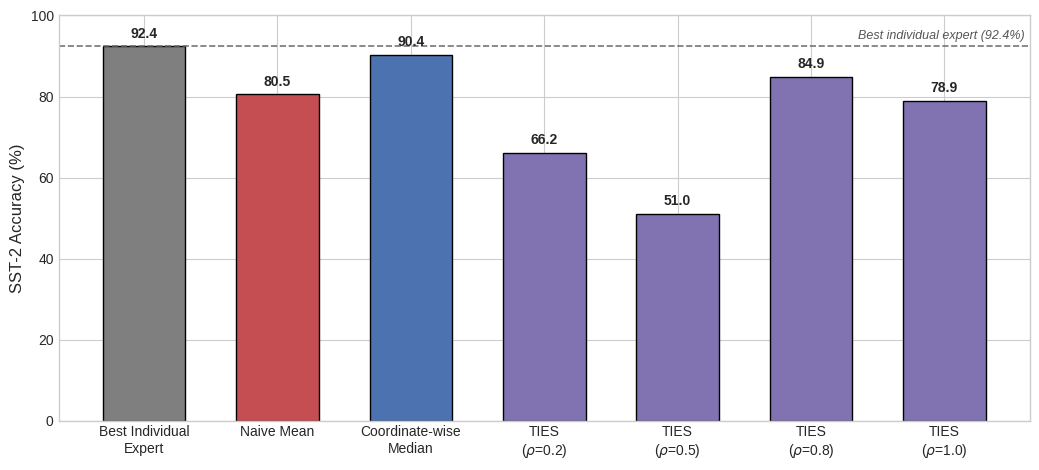

In [ ]:
import matplotlib.pyplot as plt
import os


def generate_paper_plot_bert_n3(
    results_dict,
    output_dir=".",
    filename_base="bert_n3_ablation",
    show_title=False
):
    """
    Generate a paper-style bar chart for BERT N=3 model merging results.

    Parameters
    ----------
    results_dict : dict
        Example:
        {
            'Best Individual\nExpert': 92.43,
            'Naive Mean': 80.50,
            'Coordinate-wise\nMedian': 90.37,
            'TIES\n($\\rho$=0.2)': 66.17,
            'TIES\n($\\rho$=0.5)': 51.03,
            'TIES\n($\\rho$=0.8)': 84.86,
            'TIES\n($\\rho$=1.0)': 78.90
        }

    output_dir : str
        Directory to save figures.

    filename_base : str
        Base filename without extension.

    show_title : bool
        Whether to display an internal plot title.
        For papers, False is usually better since LaTeX captions handle titles.
    """

    # Clean paper-like style
    plt.style.use("seaborn-v0_8-whitegrid")

    # Figure size tuned for paper usage
    fig, ax = plt.subplots(figsize=(10.5, 4.8))

    categories = list(results_dict.keys())
    values = list(results_dict.values())

    # Color scheme: muted and consistent
    colors = []
    for cat in categories:
        if "Best Individual" in cat:
            colors.append("#7f7f7f")   # gray
        elif "Mean" in cat:
            colors.append("#c44e52")   # muted red
        elif "Median" in cat:
            colors.append("#4c72b0")   # muted blue
        elif "TIES" in cat:
            colors.append("#8172b2")   # muted purple
        else:
            colors.append("#999999")

    bars = ax.bar(
        categories,
        values,
        color=colors,
        edgecolor="black",
        linewidth=1.0,
        width=0.62
    )

    # Best individual expert reference line
    best_expert_label = None
    best_expert_value = None
    for k, v in results_dict.items():
        if "Best Individual" in k:
            best_expert_label = k
            best_expert_value = v
            break

    if best_expert_value is not None:
        ax.axhline(
            y=best_expert_value,
            color="#666666",
            linestyle="--",
            linewidth=1.2,
            alpha=0.9
        )

        ax.text(
            len(categories) - 0.4,
            best_expert_value + 1.0,
            f"Best individual expert ({best_expert_value:.1f}%)",
            color="#555555",
            ha="right",
            va="bottom",
            fontsize=9,
            style="italic"
        )

    # Axis formatting
    ax.set_ylabel("SST-2 Accuracy (%)", fontsize=12)
    ax.set_ylim(0, 100)
    ax.tick_params(axis="x", labelsize=10)
    ax.tick_params(axis="y", labelsize=10)

    # Optional internal title
    if show_title:
        ax.set_title("BERT SST-2 Accuracy under $N=3$", fontsize=13, pad=10)

    # Value labels above bars
    for bar in bars:
        height = bar.get_height()
        ax.annotate(
            f"{height:.1f}",
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 4),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )

    # Keep a neat boxed frame
    ax.spines["top"].set_visible(True)
    ax.spines["right"].set_visible(True)

    plt.tight_layout()

    os.makedirs(output_dir, exist_ok=True)
    pdf_path = os.path.join(output_dir, f"{filename_base}.pdf")
    png_path = os.path.join(output_dir, f"{filename_base}.png")

    # Save both PDF and PNG
    plt.savefig(pdf_path, bbox_inches="tight")
    plt.savefig(png_path, dpi=300, bbox_inches="tight")

    print(f"[Saved] PDF: {pdf_path}")
    print(f"[Saved] PNG: {png_path}")

    plt.show()


if __name__ == "__main__":
    bert_n3_results = {
        "Best Individual\nExpert": 92.43,
        "Naive Mean": 80.50,
        "Coordinate-wise\nMedian": 90.37,
        "TIES\n($\\rho$=0.2)": 66.17,
        "TIES\n($\\rho$=0.5)": 51.03,
        "TIES\n($\\rho$=0.8)": 84.86,
        "TIES\n($\\rho$=1.0)": 78.90
    }

    generate_paper_plot_bert_n3(
        results_dict=bert_n3_results,
        output_dir=".",
        filename_base="bert_n3_ablation",
        show_title=False
    )

In [ ]:
import os
from huggingface_hub import snapshot_download

# Define model repository directory
base_dir = '/content/drive/MyDrive/STAD68H3_Model_Merging/models'
os.makedirs(base_dir, exist_ok=True)

# 1. Define the 4 NEW domain-specific experts to reach N=7
new_models_to_download = {
    "FineTuned_MRPC": "textattack/bert-base-uncased-MRPC", # Paraphrase detection
    "FineTuned_QNLI": "textattack/bert-base-uncased-QNLI", # Question NLI
    "FineTuned_RTE": "textattack/bert-base-uncased-RTE",   # Recognizing Textual Entailment
    "FineTuned_CoLA": "textattack/bert-base-uncased-CoLA"  # Linguistic Acceptability
}

print("[Info] Starting download of 4 additional expert models for N=7...")

for folder_name, repo_id in new_models_to_download.items():
    save_path = os.path.join(base_dir, folder_name)
    if not os.path.exists(save_path):
        print(f"[*] Downloading {folder_name} ({repo_id})...")
        snapshot_download(
            repo_id=repo_id,
            local_dir=save_path,
            ignore_patterns=["*.h5", "*.ot", "*.msgpack", "*.flax"]
        )
        print(f"[+] Successfully saved {folder_name}.\n")
    else:
        print(f"[-] {folder_name} already exists. Skipping.")

print("[Success] All 7 expert models are now securely stored in your Drive!")

[Info] Starting download of 4 additional expert models for N=7...
[-] FineTuned_MRPC already exists. Skipping.
[-] FineTuned_QNLI already exists. Skipping.
[-] FineTuned_RTE already exists. Skipping.
[-] FineTuned_CoLA already exists. Skipping.
[Success] All 7 expert models are now securely stored in your Drive!


In [ ]:
import torch
import os
from transformers import AutoModelForSequenceClassification, AutoTokenizer, AutoModel
from datasets import load_dataset
from tqdm import tqdm

# ==========================================
# 1. Directory & Environment Setup
# ==========================================
models_dir = '/content/drive/MyDrive/STAD68H3_Model_Merging/models'
output_base_dir = '/content/drive/MyDrive/STAD68H3_Model_Merging/N7_Experiments'
os.makedirs(output_base_dir, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[Info] Active device: {device}")

# ==========================================
# 2. Core Mathematical Merging Functions
# ==========================================
def apply_mean_merging(base_sd, expert_sds):
    print("[Info] Executing Naive Mean Merging...")
    merged_sd = {}
    for key in base_sd.keys():
        tensors = [sd[key] for sd in expert_sds]
        if all(t.shape == tensors[0].shape for t in tensors):
            stacked = torch.stack(tensors, dim=0).float()
            merged_sd[key] = torch.mean(stacked, dim=0)
        else:
            merged_sd[key] = base_sd[key]
    return merged_sd

def apply_median_merging(base_sd, expert_sds):
    print("[Info] Executing Coordinate-wise Median Merging...")
    merged_sd = {}
    for key in base_sd.keys():
        tensors = [sd[key] for sd in expert_sds]
        if all(t.shape == tensors[0].shape for t in tensors):
            stacked = torch.stack(tensors, dim=0).float()
            merged_sd[key] = torch.median(stacked, dim=0)[0]
        else:
            merged_sd[key] = base_sd[key]
    return merged_sd

def apply_ties_merging(base_sd, expert_sds, density):
    print(f"[Info] Executing TIES-Merging (Density: {density:.2f})...")
    merged_sd = {}
    for key in base_sd.keys():
        base_weights = base_sd[key]
        task_vectors = [expert_sd[key] - base_weights for expert_sd in expert_sds]

        trimmed_tvs = []
        for tv in task_vectors:
            k = max(1, int(tv.numel() * density))
            _, indices = torch.topk(tv.abs().flatten(), k)
            mask = torch.zeros_like(tv.flatten())
            mask[indices] = 1.0
            trimmed_tvs.append((tv.flatten() * mask).view(tv.shape))

        stacked_tvs = torch.stack(trimmed_tvs, dim=0)
        summed_tv = stacked_tvs.sum(dim=0)
        consensus_sign = torch.sign(summed_tv)

        valid_mask = (torch.sign(stacked_tvs) == consensus_sign.unsqueeze(0)) & (consensus_sign.unsqueeze(0) != 0)
        filtered_tvs = stacked_tvs * valid_mask

        non_zero_counts = valid_mask.sum(dim=0).clamp(min=1)
        merged_tv = filtered_tvs.sum(dim=0) / non_zero_counts

        merged_sd[key] = base_weights + merged_tv
    return merged_sd

# ==========================================
# 3. Memory & Model Management (Loading N=7)
# ==========================================
print("\n[Info] Loading Base Model and 7 Experts into RAM...")
base_model = AutoModel.from_pretrained(f"{models_dir}/Base_Model")
base_sd = base_model.state_dict()
tokenizer = AutoTokenizer.from_pretrained(f"{models_dir}/Base_Model")

expert_names = [
    "FineTuned_SST2", "FineTuned_MNLI", "FineTuned_QQP",
    "FineTuned_MRPC", "FineTuned_QNLI", "FineTuned_RTE", "FineTuned_CoLA"
]

expert_sds = []
for name in expert_names:
    expert_path = os.path.join(models_dir, name)
    expert_sds.append(AutoModel.from_pretrained(expert_path).state_dict())

print("[Success] All 7 experts successfully loaded.")

# ==========================================
# 4. Generate All N=7 Merged Models
# ==========================================
models_to_test = {}

# 4.1 Mean & Median
mean_sd = apply_mean_merging(base_sd, expert_sds)
median_sd = apply_median_merging(base_sd, expert_sds)

# Helper function to save model
def save_model(state_dict, folder_name):
    path = os.path.join(output_base_dir, folder_name)
    base_model.load_state_dict(state_dict)
    base_model.save_pretrained(path)
    tokenizer.save_pretrained(path)
    return path

models_to_test['Naive_Mean_N7'] = save_model(mean_sd, "Mean_N7")
models_to_test['Coordinate_Median_N7'] = save_model(median_sd, "Median_N7")

# 4.2 TIES Ablation
densities = [0.2, 0.5, 0.8, 1.0]
for d in densities:
    ties_sd = apply_ties_merging(base_sd, expert_sds, density=d)
    models_to_test[f'TIES_N7_d{d}'] = save_model(ties_sd, f"TIES_N7_{d}")

print("[Success] All N=7 merged architectures generated and saved to Drive.")

# ==========================================
# 5. The Ultimate N=7 Benchmark
# ==========================================
print("\n[Info] Downloading and loading SST-2 validation dataset...")
dataset = load_dataset("glue", "sst2", split="validation")

def evaluate_model(model_path, is_merged=True):
    model_name = model_path.split('/')[-1]
    model = AutoModelForSequenceClassification.from_pretrained(f"{models_dir}/FineTuned_SST2").to(device)

    if is_merged:
        merged_encoder = AutoModel.from_pretrained(model_path).to(device)
        model.bert = merged_encoder

    model.eval()
    correct = 0
    with torch.no_grad():
        for example in tqdm(dataset, desc=f"Evaluating {model_name}"):
            inputs = tokenizer(example['sentence'], return_tensors="pt", truncation=True, padding=True).to(device)
            outputs = model(**inputs)
            if torch.argmax(outputs.logits, dim=-1).item() == example['label']:
                correct += 1
    return correct / len(dataset)

print("\n" + "="*50)
print("🏆 INITIATING N=7 GRAND BENCHMARK 🏆")
print("="*50)

results = {}
results['Expert (Upper Bound)'] = evaluate_model(f"{models_dir}/FineTuned_SST2", is_merged=False)

for name, path in models_to_test.items():
    results[name] = evaluate_model(path, is_merged=True)

print("\n" + "="*50)
print("FINAL N=7 EXPERIMENTAL RESULTS (Accuracy %)")
print("="*50)
for name, acc in results.items():
    print(f"{name:<25}: {acc * 100:.2f}%")
print("="*50)

[Info] Active device: cuda

[Info] Loading Base Model and 7 Experts into RAM...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: /content/drive/MyDrive/STAD68H3_Model_Merging/models/Base_Model
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: /content/drive/MyDrive/STAD68H3_Model_Merging/models/FineTuned_SST2
Key               | Status     |  | 
------------------+------------+--+-
classifier.bias   | UNEXPECTED |  | 
classifier.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

Evaluating TIES_N7_0.8: 100%|██████████| 872/872 [00:07<00:00, 114.77it/s]


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Evaluating TIES_N7_1.0: 100%|██████████| 872/872 [00:07<00:00, 116.49it/s]


FINAL N=7 EXPERIMENTAL RESULTS (Accuracy %)
Expert (Upper Bound)     : 92.43%
Naive_Mean_N7            : 61.01%
Coordinate_Median_N7     : 52.41%
TIES_N7_d0.2             : 49.31%
TIES_N7_d0.5             : 65.60%
TIES_N7_d0.8             : 63.53%
TIES_N7_d1.0             : 55.28%


[Saved] PDF: ./bert_n7_ablation.pdf
[Saved] PNG: ./bert_n7_ablation.png


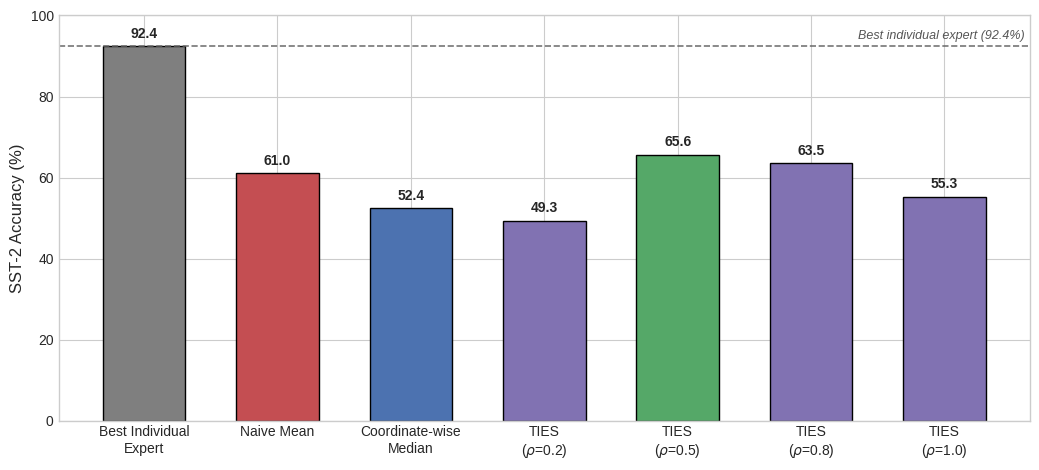

In [ ]:
import matplotlib.pyplot as plt
import os

def generate_paper_plot_bert_n7(
    results_dict,
    output_dir=".",
    filename_base="bert_n7_ablation",
    show_title=False
):
    """
    Generate a paper-style bar chart for BERT N=7 model merging results.

    Parameters
    ----------
    results_dict : dict
        Example:
        {
            'Best Individual\nExpert': 92.43,
            'Naive Mean': 61.01,
            'Coordinate-wise\nMedian': 52.41,
            'TIES\n($\\rho$=0.2)': 49.31,
            'TIES\n($\\rho$=0.5)': 65.60,
            'TIES\n($\\rho$=0.8)': 63.53,
            'TIES\n($\\rho$=1.0)': 55.28
        }
    output_dir : str
        Directory to save figures.
    filename_base : str
        Base filename without extension.
    show_title : bool
        Whether to display an internal plot title.
        For papers, False is usually better since LaTeX captions handle titles.
    """

    plt.style.use("seaborn-v0_8-whitegrid")
    fig, ax = plt.subplots(figsize=(10.5, 4.8))

    categories = list(results_dict.keys())
    values = list(results_dict.values())

    # Consistent color scheme with the N=3 figure
    colors = []
    for cat in categories:
        if "Best Individual" in cat:
            colors.append("#7f7f7f")   # gray
        elif "Naive Mean" in cat:
            colors.append("#c44e52")   # muted red
        elif "Median" in cat:
            colors.append("#4c72b0")   # muted blue
        elif "TIES" in cat and "0.5" in cat:
            colors.append("#55a868")   # muted green to highlight best TIES variant
        elif "TIES" in cat:
            colors.append("#8172b2")   # muted purple for other TIES variants
        else:
            colors.append("#999999")

    bars = ax.bar(
        categories,
        values,
        color=colors,
        edgecolor="black",
        linewidth=1.0,
        width=0.62
    )

    # Reference line for best individual expert
    best_expert = values[0]
    ax.axhline(
        y=best_expert,
        color="#666666",
        linestyle="--",
        linewidth=1.2,
        alpha=0.9
    )

    ax.text(
        len(categories) - 0.4,
        best_expert + 1.0,
        f"Best individual expert ({best_expert:.1f}%)",
        color="#555555",
        ha="right",
        va="bottom",
        fontsize=9,
        style="italic"
    )

    ax.set_ylabel("SST-2 Accuracy (%)", fontsize=12)
    ax.set_ylim(0, 100)
    ax.tick_params(axis="x", labelsize=10)
    ax.tick_params(axis="y", labelsize=10)

    if show_title:
        ax.set_title("BERT SST-2 Accuracy under $N=7$", fontsize=13, pad=10)

    # Value labels
    for bar in bars:
        height = bar.get_height()
        ax.annotate(
            f"{height:.1f}",
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 4),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )

    ax.spines["top"].set_visible(True)
    ax.spines["right"].set_visible(True)

    plt.tight_layout()

    os.makedirs(output_dir, exist_ok=True)

    pdf_path = os.path.join(output_dir, f"{filename_base}.pdf")
    png_path = os.path.join(output_dir, f"{filename_base}.png")

    plt.savefig(pdf_path, bbox_inches="tight")
    plt.savefig(png_path, dpi=300, bbox_inches="tight")

    print(f"[Saved] PDF: {pdf_path}")
    print(f"[Saved] PNG: {png_path}")

    plt.show()


if __name__ == "__main__":
    bert_n7_results = {
        'Best Individual\nExpert': 92.43,
        'Naive Mean': 61.01,
        'Coordinate-wise\nMedian': 52.41,
        'TIES\n($\\rho$=0.2)': 49.31,
        'TIES\n($\\rho$=0.5)': 65.60,
        'TIES\n($\\rho$=0.8)': 63.53,
        'TIES\n($\\rho$=1.0)': 55.28
    }

    generate_paper_plot_bert_n7(
        results_dict=bert_n7_results,
        output_dir=".",
        filename_base="bert_n7_ablation",
        show_title=False
    )

[Saved] PDF: ./bert_combined_ablation.pdf
[Saved] PNG: ./bert_combined_ablation.png


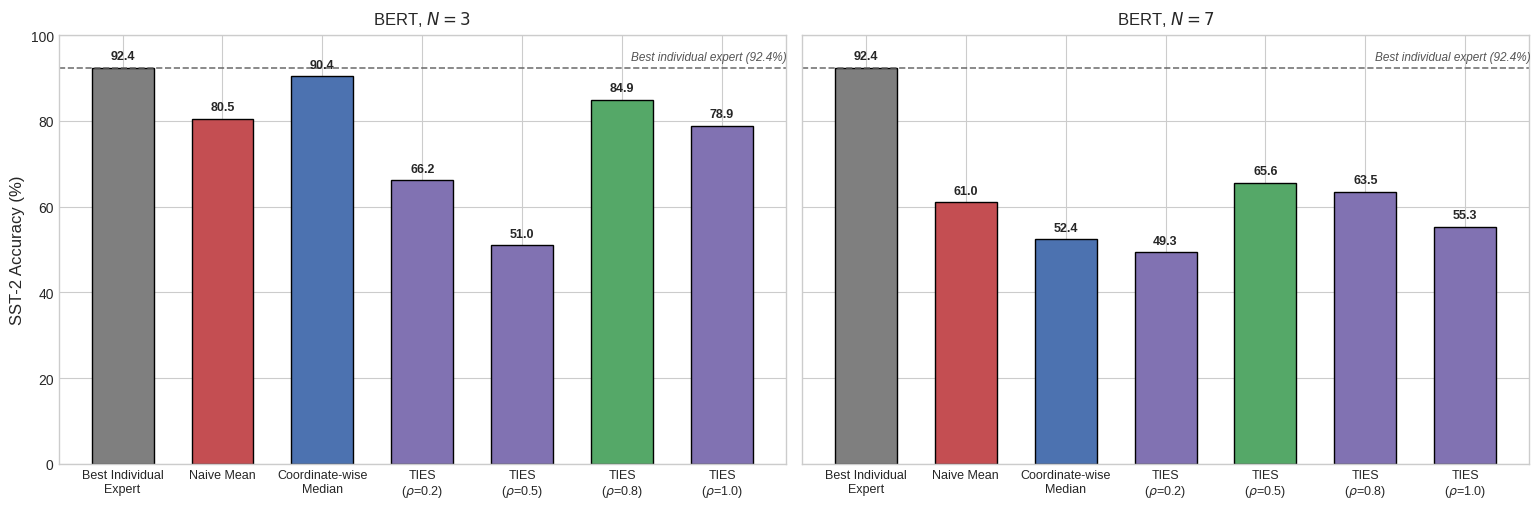

In [ ]:
import matplotlib.pyplot as plt
import os

def generate_paper_plot_bert_combined(
    results_n3,
    results_n7,
    output_dir=".",
    filename_base="bert_combined_ablation",
    show_suptitle=False
):
    """
    Generate a paper-style side-by-side figure for BERT N=3 and N=7 results.

    Parameters
    ----------
    results_n3 : dict
        Example:
        {
            'Best Individual\nExpert': 92.43,
            'Naive Mean': 80.50,
            'Coordinate-wise\nMedian': 90.37,
            'TIES\n($\\rho$=0.2)': 66.17,
            'TIES\n($\\rho$=0.5)': 51.03,
            'TIES\n($\\rho$=0.8)': 84.86,
            'TIES\n($\\rho$=1.0)': 78.90
        }

    results_n7 : dict
        Example:
        {
            'Best Individual\nExpert': 92.43,
            'Naive Mean': 61.01,
            'Coordinate-wise\nMedian': 52.41,
            'TIES\n($\\rho$=0.2)': 49.31,
            'TIES\n($\\rho$=0.5)': 65.60,
            'TIES\n($\\rho$=0.8)': 63.53,
            'TIES\n($\\rho$=1.0)': 55.28
        }

    output_dir : str
        Directory to save figures.
    filename_base : str
        Base filename without extension.
    show_suptitle : bool
        Whether to display an overall figure title inside the image.
        For papers, False is usually better.
    """

    plt.style.use("seaborn-v0_8-whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(15.5, 5.2), sharey=True)

    def get_colors(categories, values):
        # Highlight the best TIES variant among merged methods only
        ties_indices = [i for i, cat in enumerate(categories) if "TIES" in cat]
        best_ties_idx = None
        if ties_indices:
            best_ties_idx = max(ties_indices, key=lambda i: values[i])

        colors = []
        for i, cat in enumerate(categories):
            if "Best Individual" in cat:
                colors.append("#7f7f7f")   # gray
            elif "Naive Mean" in cat:
                colors.append("#c44e52")   # muted red
            elif "Median" in cat:
                colors.append("#4c72b0")   # muted blue
            elif "TIES" in cat and i == best_ties_idx:
                colors.append("#55a868")   # muted green for best TIES
            elif "TIES" in cat:
                colors.append("#8172b2")   # muted purple
            else:
                colors.append("#999999")
        return colors

    def plot_single_panel(ax, results_dict, panel_title):
        categories = list(results_dict.keys())
        values = list(results_dict.values())
        colors = get_colors(categories, values)

        bars = ax.bar(
            categories,
            values,
            color=colors,
            edgecolor="black",
            linewidth=1.0,
            width=0.62
        )

        best_expert = values[0]
        ax.axhline(
            y=best_expert,
            color="#666666",
            linestyle="--",
            linewidth=1.2,
            alpha=0.9
        )

        ax.text(
            len(categories) - 0.35,
            best_expert + 1.0,
            f"Best individual expert ({best_expert:.1f}%)",
            color="#555555",
            ha="right",
            va="bottom",
            fontsize=8.5,
            style="italic"
        )

        ax.set_title(panel_title, fontsize=12, pad=8)
        ax.set_ylim(0, 100)
        ax.tick_params(axis="x", labelsize=9)
        ax.tick_params(axis="y", labelsize=10)

        for bar in bars:
            height = bar.get_height()
            ax.annotate(
                f"{height:.1f}",
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 4),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=9,
                fontweight="bold"
            )

        ax.spines["top"].set_visible(True)
        ax.spines["right"].set_visible(True)

    plot_single_panel(axes[0], results_n3, r"BERT, $N=3$")
    plot_single_panel(axes[1], results_n7, r"BERT, $N=7$")

    axes[0].set_ylabel("SST-2 Accuracy (%)", fontsize=12)

    if show_suptitle:
        fig.suptitle("BERT Ablation under Mild and Extreme Heterogeneity", fontsize=14, y=1.02)

    plt.tight_layout()

    os.makedirs(output_dir, exist_ok=True)

    pdf_path = os.path.join(output_dir, f"{filename_base}.pdf")
    png_path = os.path.join(output_dir, f"{filename_base}.png")

    plt.savefig(pdf_path, bbox_inches="tight")
    plt.savefig(png_path, dpi=300, bbox_inches="tight")

    print(f"[Saved] PDF: {pdf_path}")
    print(f"[Saved] PNG: {png_path}")

    plt.show()


if __name__ == "__main__":
    bert_n3_results = {
        'Best Individual\nExpert': 92.43,
        'Naive Mean': 80.50,
        'Coordinate-wise\nMedian': 90.37,
        'TIES\n($\\rho$=0.2)': 66.17,
        'TIES\n($\\rho$=0.5)': 51.03,
        'TIES\n($\\rho$=0.8)': 84.86,
        'TIES\n($\\rho$=1.0)': 78.90
    }

    bert_n7_results = {
        'Best Individual\nExpert': 92.43,
        'Naive Mean': 61.01,
        'Coordinate-wise\nMedian': 52.41,
        'TIES\n($\\rho$=0.2)': 49.31,
        'TIES\n($\\rho$=0.5)': 65.60,
        'TIES\n($\\rho$=0.8)': 63.53,
        'TIES\n($\\rho$=1.0)': 55.28
    }

    generate_paper_plot_bert_combined(
        results_n3=bert_n3_results,
        results_n7=bert_n7_results,
        output_dir=".",
        filename_base="bert_combined_ablation",
        show_suptitle=False
    )